In [1]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
from ggTrader.Backtest import Backtest
import matplotlib.pyplot as plt
import matplotlib.ticker as tck  # Import the ticker module
import seaborn as sns



In [2]:

top20_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

In [3]:
# Ticker

symbols = ["BTC"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-06-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 12)
# start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3  #atr multiplier for chandelier exit
adx_threshold = 25  #trend strength
ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
# init_cash = 1000

#
k = KrakenHistoricalData()
s = Signals()
# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)

print(df_multi.head())

# remove multi-index
print(start)
print(end)

df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.info())
print(df.head())
print(df.tail())

                                    BTC                              \
                                   open          high           low   
2023-01-01 00:00:00+00:00  16528.699219  16530.000000  16505.199219   
2023-01-01 04:00:00+00:00  16519.300781  16542.400391  16506.900391   
2023-01-01 08:00:00+00:00  16512.400391  16538.400391  16490.000000   
2023-01-01 12:00:00+00:00  16500.199219  16550.000000  16497.699219   
2023-01-01 16:00:00+00:00  16550.000000  16573.099609  16531.199219   

                                                                         
                                  close        volume trades base quote  
2023-01-01 00:00:00+00:00  16519.300781  2.636628e+10    803  BTC   USD  
2023-01-01 04:00:00+00:00  16510.699219  1.122105e+11   2919  BTC   USD  
2023-01-01 08:00:00+00:00  16500.199219  1.014384e+11   2536  BTC   USD  
2023-01-01 12:00:00+00:00  16549.900391  2.684441e+10   2002  BTC   USD  
2023-01-01 16:00:00+00:00  16553.699219  3.952236e+10   24

In [4]:
# Calculate indicators
signals = s.calc_signals(df.copy())
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
print(f"\nSignals:")
print(signals.info())
print(signals.head())
print(signals.tail())



                                    sar  sar_s  adx  adx_d  adx_dmp  adx_dmn  \
2024-07-05 00:00:00+00:00           NaN  False  NaN    NaN      NaN      NaN   
2024-07-05 04:00:00+00:00  53563.300781   True  NaN    NaN      NaN      NaN   
2024-07-05 08:00:00+00:00  53563.300781   True  NaN    NaN      NaN      NaN   
2024-07-05 12:00:00+00:00  53645.828750   True  NaN    NaN      NaN      NaN   
2024-07-05 16:00:00+00:00  53824.885119   True  NaN    NaN      NaN      NaN   

                           adx_s  adx_bullish  entry_signal          open  \
2024-07-05 00:00:00+00:00  False        False         False  57031.398438   
2024-07-05 04:00:00+00:00  False        False         False  55210.000000   
2024-07-05 08:00:00+00:00  False        False         False  54335.000000   
2024-07-05 12:00:00+00:00  False        False         False  55473.699219   
2024-07-05 16:00:00+00:00  False        False         False  56630.101562   

                           ...  trades  base  quote  atr

In [5]:
# Backtest
bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee)
bt.run()
stats = bt.stats

print(f"\nBacktest Stats:")
print(tabulate(stats.items(), headers=['Metric', 'Value'], tablefmt='github'))



Backtest Stats:
| Metric         |       Value |
|----------------|-------------|
| wins           |   11        |
| loss           |   13        |
| win_rate       |    0.458333 |
| trading_days   |  360        |
| sharpe_ratio   |   15.0387   |
| sortino_ratio  |  103.24     |
| total_trades   |   24        |
| ave_profit     | 1655.66     |
| std_profit     | 5912.95     |
| ave_profit_pct |    2.49186  |
| std_profit_pct |    7.75421  |


In [6]:
##  Boolean where in position
y1_arr = signals['close'].values
in_position = pd.Series(pd.NA, index=filtered_entry.index, dtype="boolean")
in_position[filtered_entry] = filtered_entry[filtered_entry]
in_position[filtered_exit] = ~filtered_exit[filtered_exit]
in_position.ffill(inplace=True)
y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

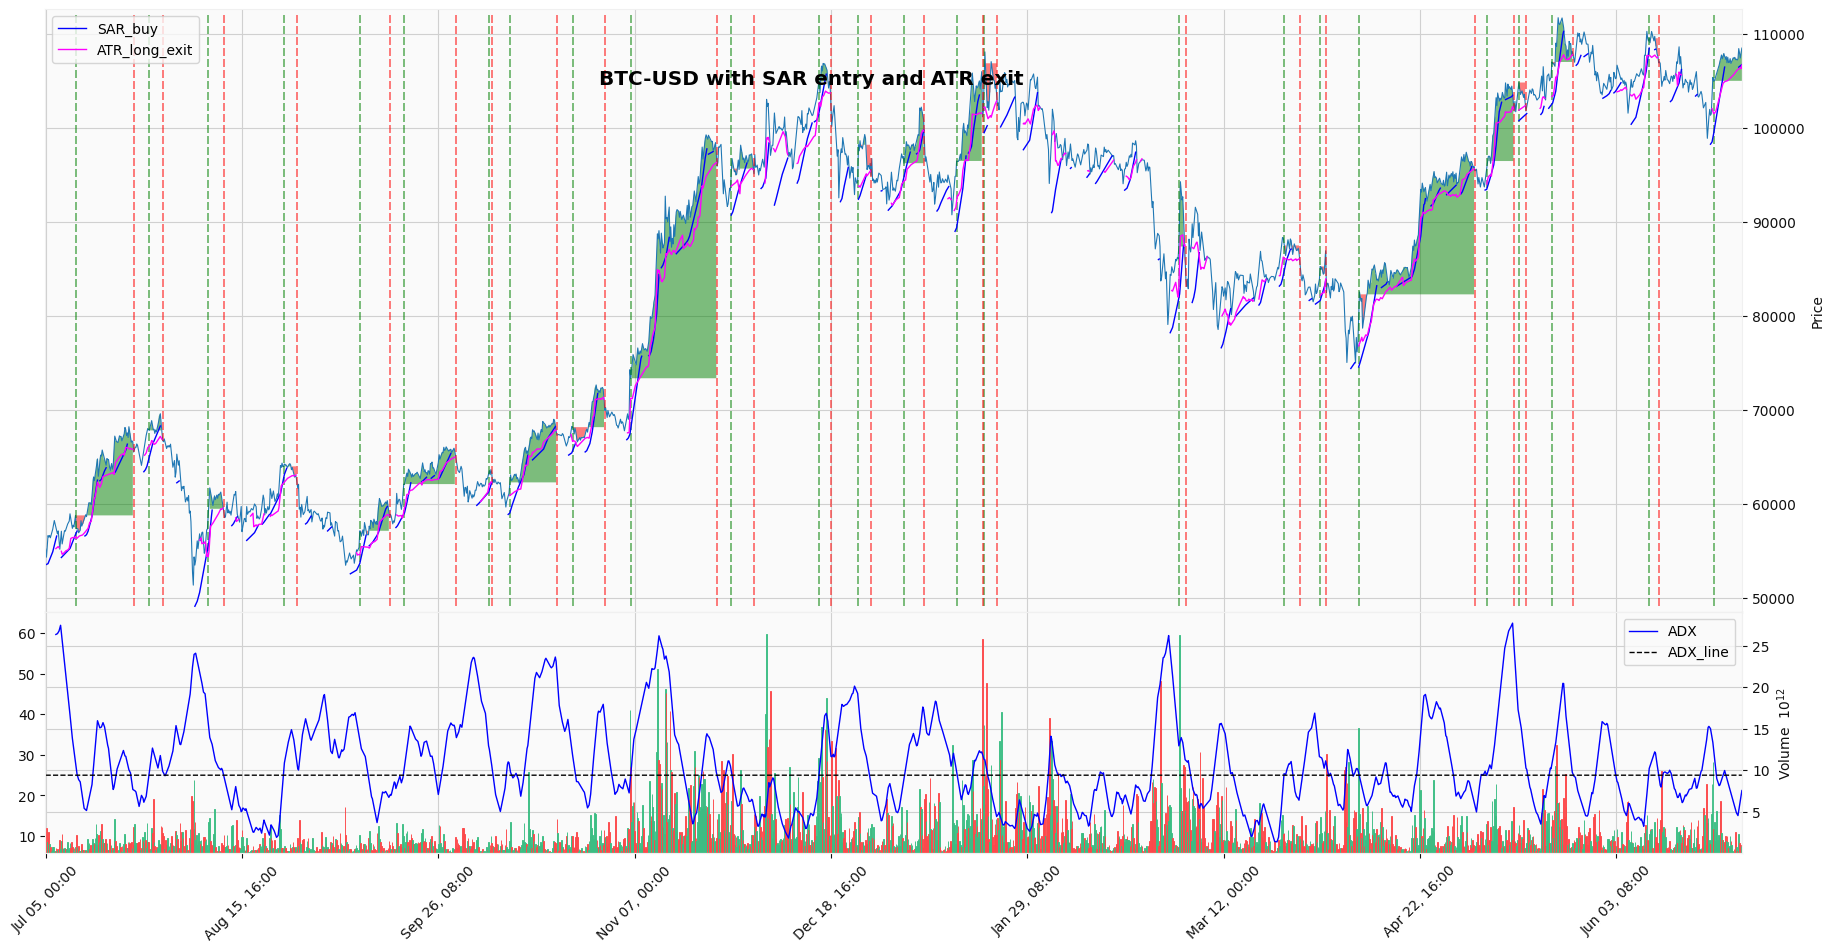

In [7]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),
    # mpf.make_addplot(signals['ce_sh'], type='line', width=1.0, label='ATR_short_exit',
    #                  secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', color='blue', width=1.0, label='ADX', panel=1),
    # mpf.make_addplot(signals['adx_dmp'], type='line', linestyle='--', width=1.0, label='dmp', panel=1),
    # mpf.make_addplot(signals['adx_dmn'], type='line', linestyle='--', width=1.0, label='dmn', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),
    # mpf.make_addplot(profit_cum, type='line', width=1.0, label='Profit', panel=2),
    # mpf.make_addplot(zero_line, type='line', color="black", linestyle='--', width=1.0, label='Zero_line', panel=2,
    #                  secondary_y=False),
    # mpf.make_addplot(profit, type='scatter', panel=3),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)


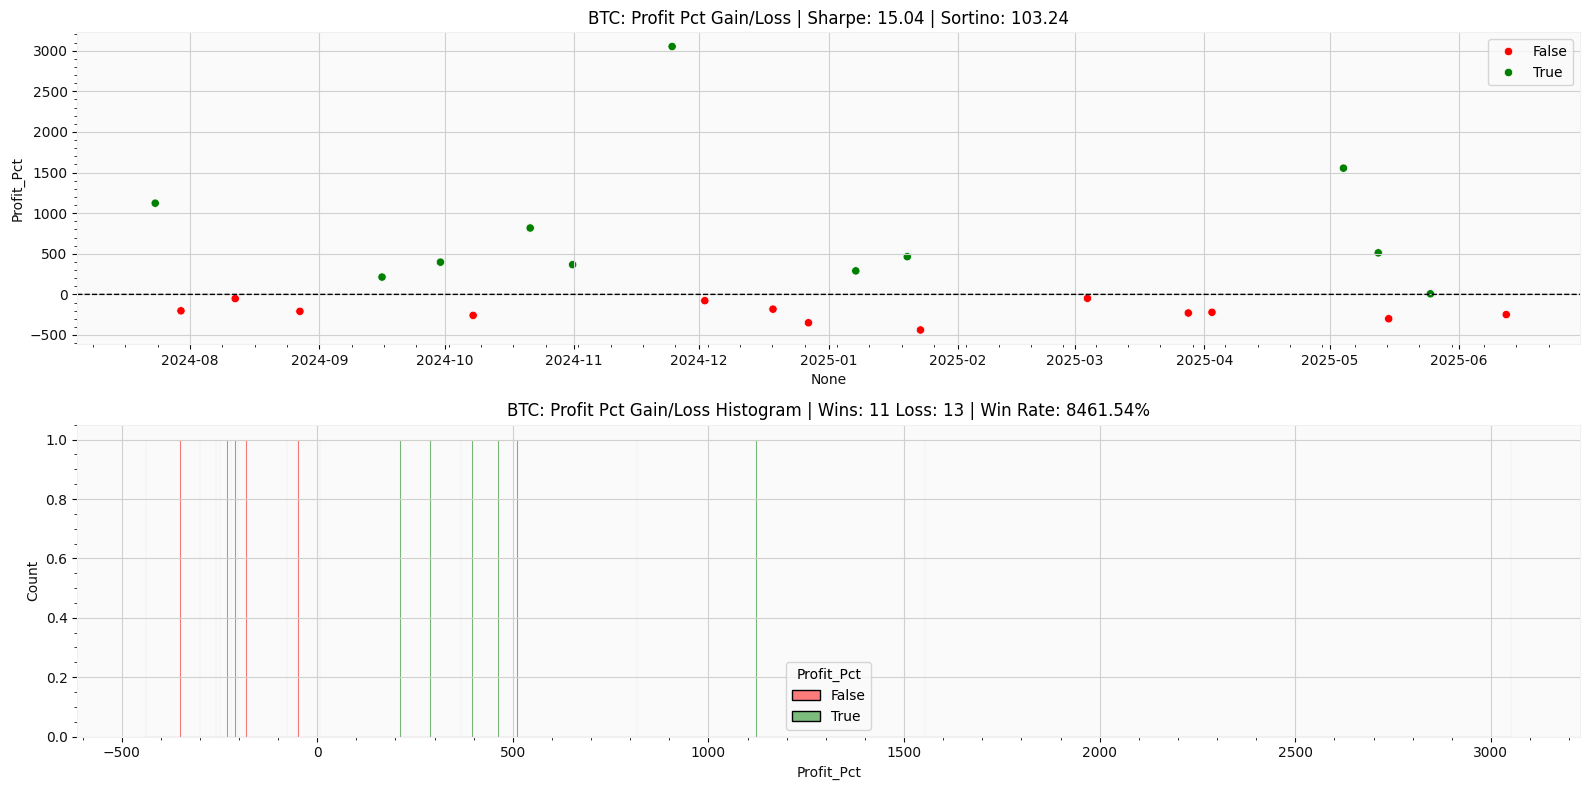

In [8]:
profit_df = bt.profit_df
wins = stats['wins']
loss = stats['loss']
sharpe = stats['sharpe_ratio']
sortino = stats['sortino_ratio']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))  # wider figure

sns.scatterplot(data=profit_df, x=profit_df.index, y=profit_df['Profit_Pct'] * 100, hue=profit_df['Profit_Pct'] > 0,
                palette={True: 'green', False: 'red'}, ax=axes[0])
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0, ax=axes[0])
axes[0].set_title(f"{symbols[0]}: Profit Pct Gain/Loss | Sharpe: {sharpe:.2f} | Sortino: {sortino:.2f}")
axes[0].minorticks_on()

axes[0].set_xlim(start, end)

# fig3 = plt.figure(figsize=(16, 4))  # wider figure
sns.histplot(profit_df,
             x=profit_df['Profit_Pct'] * 100,
             hue=profit_df['Profit_Pct'] > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[1]
             )
axes[1].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {wins} Loss: {loss} | Win Rate: {wins / loss * 100:.2%}")
axes[1].minorticks_on()
plt.tight_layout()
plt.show()